✅ Dataset Created!
   size_sqft  bedrooms  bathrooms  age_years  garage  location_score   price
0       1360         1          1          7       1               8  391107
1       4272         1          3         49       1               4  759899
2       3592         3          3         27       0               1  607829
3        966         3          1         27       1               4  277354
4       4926         3          3         36       1               7  934756

Dataset Shape: (200, 7)

📊 Basic Statistics:
         size_sqft    bedrooms   bathrooms   age_years      garage  \
count   200.000000  200.000000  200.000000  200.000000  200.000000   
mean   2765.835000    2.995000    1.900000   23.860000    1.040000   
std    1238.219332    1.440608    0.844729   14.639398    0.807254   
min     534.000000    1.000000    1.000000    0.000000    0.000000   
25%    1773.000000    2.000000    1.000000   12.000000    0.000000   
50%    2845.000000    3.000000    2.000000   25.00000

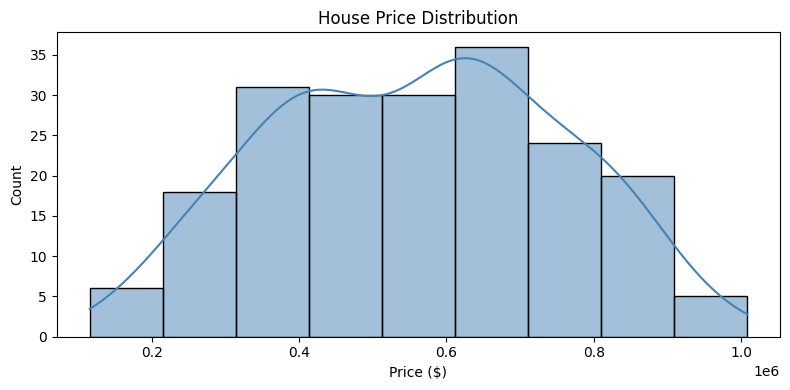

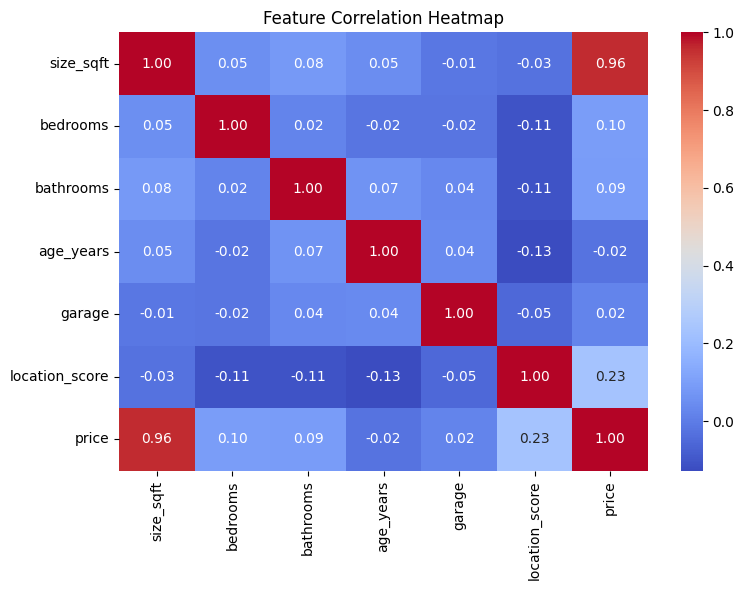

✅ Data Split Done!
   Training samples : 160
   Testing  samples : 40

✅ Model Trained Successfully!

Feature Coefficients:
   size_sqft: 190,134.58
   bedrooms: 14,334.04
   bathrooms: 6,643.07
   age_years: -7,653.87
   garage: 9,986.44
   location_score: 52,991.48

📊 Model Performance:
   RMSE     : $12,660.27
   R² Score : 0.9952  (closer to 1.0 = better)


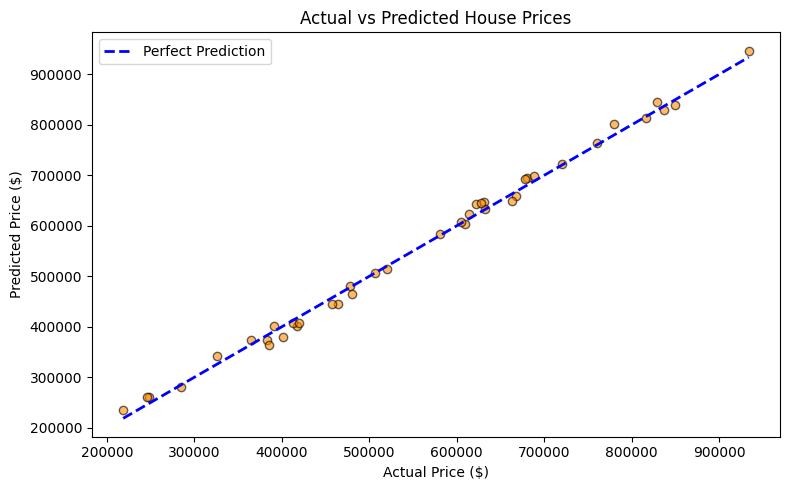


🏠 New House Details:
   Size      : 2000 sqft
   Bedrooms  : 3
   Bathrooms : 2
   Age       : 10 years
   Garage    : 1
   Location  : 7/10

💰 Predicted Price : $493,739.97

✅ Project Complete!


In [1]:
# ============================================================
# HOUSE PRICE PREDICTION - COMPLETE CODE
# ============================================================

# CELL 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ============================================================
# CELL 2 - Create Dataset
np.random.seed(42)
n = 200

data = {
    'size_sqft':      np.random.randint(500, 5000, n),
    'bedrooms':       np.random.randint(1, 6, n),
    'bathrooms':      np.random.randint(1, 4, n),
    'age_years':      np.random.randint(0, 50, n),
    'garage':         np.random.randint(0, 3, n),
    'location_score': np.random.randint(1, 10, n),
}

df = pd.DataFrame(data)

df['price'] = (
    df['size_sqft'] * 150 +
    df['bedrooms'] * 10000 +
    df['bathrooms'] * 8000 -
    df['age_years'] * 500 +
    df['garage'] * 12000 +
    df['location_score'] * 20000 +
    np.random.randint(-20000, 20000, n)
)

print("✅ Dataset Created!")
print(df.head())
print(f"\nDataset Shape: {df.shape}")

# ============================================================
# CELL 3 - Explore Data
print("\n📊 Basic Statistics:")
print(df.describe())
print("\nMissing Values:\n", df.isnull().sum())

plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, color='steelblue')
plt.title('House Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ============================================================
# CELL 4 - Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# ============================================================
# CELL 5 - Prepare Data
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Data Split Done!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing  samples : {X_test.shape[0]}")

# ============================================================
# CELL 6 - Train Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("\n✅ Model Trained Successfully!")
print("\nFeature Coefficients:")
for feat, coef in zip(X.columns, model.coef_):
    print(f"   {feat}: {coef:,.2f}")

# ============================================================
# CELL 7 - Evaluate Model
y_pred = model.predict(X_test_scaled)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"\n📊 Model Performance:")
print(f"   RMSE     : ${rmse:,.2f}")
print(f"   R² Score : {r2:.4f}  (closer to 1.0 = better)")

# ============================================================
# CELL 8 - Visualize Predictions
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkorange', edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'b--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# CELL 9 - Predict a New House
new_house = pd.DataFrame([{
    'size_sqft': 2000,
    'bedrooms': 3,
    'bathrooms': 2,
    'age_years': 10,
    'garage': 1,
    'location_score': 7
}])

new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)[0]

print(f"\n🏠 New House Details:")
print(f"   Size      : 2000 sqft")
print(f"   Bedrooms  : 3")
print(f"   Bathrooms : 2")
print(f"   Age       : 10 years")
print(f"   Garage    : 1")
print(f"   Location  : 7/10")
print(f"\n💰 Predicted Price : ${predicted_price:,.2f}")
print("\n✅ Project Complete!")